# <u>Neural Networks for Regression</u>

### Prerequisites:
* <a href="../../Supervised ML Basis.ipynb">Check out the notebook on Supervised ML Basics</a>

## Topics

* [1. Core idea](#idea)
* [**2.1 Regression**](#reg)
* [2.2 Classification](#class)
    * <a href="../../2.Classification/11.Artificial Neural Networks/Neural Networks for Classification.ipynb">Check out the notebook on Neural Networks for Classification</a>

* [Neural Networks for Regression library](#library)

    

In [2]:
import numpy as np  # for random numbers and numpy arrays
import pandas as pd # for dataframes
import matplotlib.pyplot as plt # for 2D Plots
import plotly.express as px # for 3D Plots
import plotly.graph_objects as go # for 3D Plots

# Neural network classes
import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
#print(sklearn.__version__)

# Pytorch
import torch # Deep learning and neural networks
import torch.nn as nn
#print(torch.__version__)

# Tensorflow (Deep learning framework)
import tensorflow as tf # High-level neural network API
from tensorflow import keras 
#print(tf.__version__)

print("Setup complete")

Setup complete


<a class="anchor" id="perceptron"></a>

# 1. Preceptron

**The Perceptron is the basic computational unit for neural networks with only one single artificial neuron**

<p align="center">
<img src="pics/1.png" width="400"/>
</p>

- Input layer: $x_1,\ldots,x_p$ are the input features
- $w_1,\ldots,w_p$ are the weights with bias term $b$
- One output neuron: $f(x)=\tau(w_1x_1 + \ldots + w_px_p + b)=\tau(w^\top x + b)$ with acitivation function $\tau$ 

### Choices for activation functions:
- Identity function (Linear Regression)
$$
f(x)=\tau (w^\top x) = w^\top x 
$$

- Logistic function (Logistic Regression)
$$
f(x) = \tau(w^\top x) = \frac{1}{1+ \exp(-w^\top x)}
$$

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- A $p$-dimensional input vector $x$ is presented by $p$ nodes in the input layer
- Consider a perceptron with 3-dimensional input vector $x$
$$
f(x)=\tau(w_1x_1+w_2x_2 + w_3x_3 + b)
$$

<p align="center">
<img src="pics/2.png" width="150"/>
</p>


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Weights $w$ are connected to edges from the input layer
- Since this is a perceptron there are as many weights as the dimension of the input vector
- The bias term $b$ is often not visualized as separate node

<p align="center">
<img src="pics/3.png" width="350"/>
</p>


</div>
</div>

---

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- To visualize the bias $b$ as a node  add a constant feature to the input vector $\tilde{x}=(1,x_1,\ldots,x_p)^\top$
- Add the bias $b$ to the weights vector $\tilde{w}=(b,w_1,\ldots,w_p)$

<p align="center">
<img src="pics/4.png" width="250"/>
</p>


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Computation $\tau(w_1x_1+w_2x_2+w_3x_3 + b)$ with activation function $\tau$ is represented by the neuron in the output layer

<p align="center">
<img src="pics/5.png" width="350"/>
</p>


</div>
</div>

### A neuron performs a 2-step computation:

**1. Affine Transformation: Weighted sum of inputs plus the bias**
- The neuron first perfroms the affine transformation

<p align="center">
<img src="pics/6.png" width="350"/>
</p>

**2. Non-linear Activation: A non-linear transformation applied to the weighted sum**
- The neuron then perfroms the non-linear transformation

<p align="center">
<img src="pics/7.png" width="350"/>
</p>

Hypothesis space formed by a single neuron is $$\mathcal{H}=\left\{f:\mathbb{R}^p \rightarrow \mathbb{R} \mid f(x)=\tau \left(\sum_{j=1}^p w_j x_j + b\right), w \in \mathbb{R}^p, b \in \mathbb{R} \right\}$$


### Perceptron Optimization

Optimize by minimizing empirical risk $$\mathcal{R}_{\text{emp}}=\frac{1}{n} \sum_{i=1}^n \underbrace{L(y^{(i)},f(x^{(i)}))}_{\text{loss function}}$$

* For Regression tasks usually choose L2 loss as loss function $$L(y,f(x))=\frac{1}{2} (y-f(x))^2$$
* For Classification tasks usually choose Entropy /Bernoulli loss as loss function $$L(y,f(x)) = - \left(y\log(f(x))+(1-y)\log(1-f(x))\right)$$

- Both L2 loss and Entropy loss are convex so global minimum can be found e.g. with gradient descent

<a class="anchor" id="single"></a>

# 2. Single Hidden Layer Neural Networks (Multi-Layer Perceptron)

### Motivation

- Individual neurons can be used as building blocks of
more complicated functions
- Networks of neurons can represent extremely complex hypothesis
spaces

##### Example

**Since single neurons are restricted to learning only linear decision boundaries it perfroms poor on data that is not linearly separable**

<p align="center">
<img src="pics/8_.png" width="550"/>
</p>

**The neuron can easily separate the classes if the original features are transformed to a new feature space**

<p align="center">
<img src="pics/9_.png" width="700"/>
</p>

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Add a single hidden layer to this Perceptron

<p align="center">
<img src="pics/10.png" width="300"/>
</p>


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

- Single Hidden Layer leads to a more complex neural network

<p align="center">
<img src="pics/11.png" width="600"/>
</p>


</div>
</div>

**Single Hidden Layer networks consist of**
- an input layer
- a hidden layer that has a set of neurons
    - each neuron in the hidden layer perfroms a 2-step computation (affine transformation and then a non-linear transformation)
- an output layer that has at least one output neuron
    - each neuron in the Output layer perfroms a final 2-step computation (affine transformation and then a non-linear transformation)


#### Single Hidden Layer networks example

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/12_.png" width="550"/>
  <img src="pics/13_.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/14_.png" width="550"/>
  <img src="pics/15_.png" width="550"/>
</div>


<p align="center">
<img src="pics/16_.png" width="600"/>
</p>

---

<p align="center">
<img src="pics/17.png" width="600"/>
</p>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/18.png" width="550"/>
  <img src="pics/19.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/20.png" width="550"/>
</div>



### Why Nonlinear Activations Are Essential

**If hidden layers do not contain nonlinear activation functions, the entire network collapses into a single linear model.**

$$
f(x)=\tau(u^\top  \sigma(W^\top x))
$$

If $\sigma$ is simply the identity function:

$$
f(x)=\tau(u^\top W^\top x)
$$

which can be rewritten as:

$$
f(x)=\tau(v^\top x)
$$

for some vector $v^\top = u^\top  W^\top$.

### Many kinds of activation functions

**ReLU Activation function (Rectified linear unit):**
- Most popular activation function choice

$$
\sigma(v) = \max(0,v)
$$


**Sigmoid Activation function:**
- Usable even in the hidden layer
- Often used for binary classification outputs

$$
\sigma(v) = \frac{1}{1+\exp(-v)}
$$


**Hyperbolic Tangent Activation function:**
- Similar to sigmoid but centered around zero

$$
\sigma(v) = \tanh(v) = \frac{\sinh(v)}{\cosh(v)} = 1-\frac{2}{\exp(2v)+1}
$$


**Softmax Activation function:**
- Usually used in the output layer for multi-class classification
- Converts scores into probabilities that sum to 1

$$
\sigma(v_i) = \frac{\exp(v_i)}{\sum_j \exp(v_j)}
$$

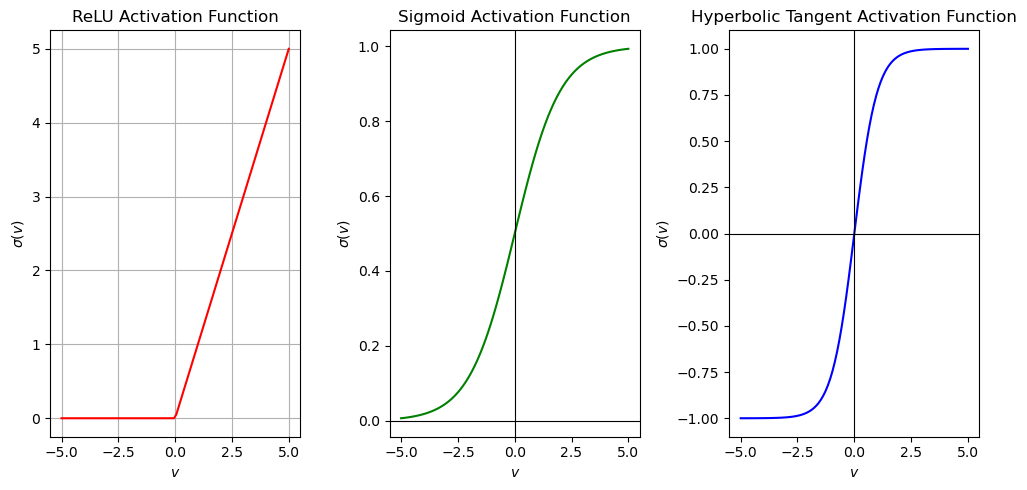

In [25]:
n = 100
v = np.linspace(-5, 5, n)

ReLU = lambda v : np.maximum(0, v)
Sigmoid = lambda v : 1 / (1 + np.exp(-v))
tanh = lambda v : 1 - 2 / (np.exp(2*v)+1)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.plot(v, ReLU(v),c="red")
plt.xlabel(r"$v$")
plt.ylabel(r"$\sigma(v)$")
plt.title("ReLU Activation Function")
plt.grid(True)


plt.subplot(1,3,2)
plt.plot(v, Sigmoid(v),c="green")
plt.xlabel(r"$v$")
plt.ylabel(r"$\sigma(v)$")
plt.title("Sigmoid Activation Function")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)



plt.subplot(1,3,3)
plt.plot(v, tanh(v),c="blue")
plt.xlabel(r"$v$")
plt.ylabel(r"$\sigma(v)$")
plt.title("Hyperbolic Tangent Activation Function")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)




plt.tight_layout()
plt.show()

<a class="anchor" id="matrix"></a>

# 4.1 Single hidden layer networks with one Output neuron

**Single hidden layer networks with one Output neuron are for Regression and binary classification**

- Input $x$ is a vector of shape $p \times 1$
- Collect all weights into a weight matrix $W$ of shape $p \times m$
$$
W = \begin{pmatrix} w_{1,1} & w_{1,2} & \ldots & w_{1,m} \\ 
w_{2,1} & w_{2,2} & \ldots & w_{2,m} \\
\vdots & \vdots & \ddots & \vdots \\
w_{p,1} & w_{p,2} & \ldots & w_{p,m}   
\end{pmatrix}
$$

- Obtain $z_1$ (neuron in hidden layer with bias term $b_1$) by picking the first column of $W$ which is $$W_1=\begin{pmatrix} w_{1,1} \\ w_{2,1} \\ \vdots \\ w_{p,1} \end{pmatrix}$$ and perform the affine transformation $W_1^\top x + b_1$ and then a non-linear transformation $\sigma(W_1^\top x + b_1)$ with the activation function $\sigma : \mathbb{R} \rightarrow \mathbb{R}$
- The single hidden layer networks with one output neuron has $m$ hidden neurons $z_1,\ldots,z_m$ in its hidden layer with $z_j = \sigma(W_j^\top x + b_j)$
    - $z_{\text{in},j}=W_j^\top x + b_j$ (affine transformation) for $j \in \{1,\ldots,m\}$
    - $z_{\text{out},j}=\sigma(z_{\text{in},j})=\sigma(W_j^\top x + b_j)$ (non-linear transformation) for $j \in \{1,\ldots,m\}$
- In vector notation it reads $z_{\text{in}}=(z_{\text{in},1},\ldots,z_{\text{in},m})^\top=W^\top x + b$ with $b=(b_1,\ldots,b_m)$
    - $z=z_{\text{out}}=\sigma(z_{\text{in}})=\sigma(W^\top x + b)$
    - the (hidden-layer) activation function $\sigma$ works element-wise on $z_{\text{in}}$
- For Regression or binary classification tasks with one output neuron the affine transformations in the hidden layer are computed as $f_{\text{in}}=u^\top z + c$ and the output is $f(x)=f_{\text{out}}=\tau(f_{\text{in}})=\tau(u^\top z + c)$ with output activation function $\tau$
    - For regression tasks $\tau$ is the identity function and for binary classification $\tau$ is the sigmoid function
- 


# 4.2 Single hidden layer networks with multiple Output neurons  





# 4.3 Multi-layer feedforward networks with multiple hidden layers and output neurons 

<a class="anchor" id="multiclass"></a>

# 4. Multiclass Classification


<a class="anchor" id="multiclass"></a>

# 5. Softmax Output Layer

<a class="anchor" id="multiclass"></a>

# 6. Softmax Loss

<a class="anchor" id="deep"></a>

# 7. Deep Feedforward Networks

<a class="anchor" id="neural"></a>

# 8. Training Neural Networks

<a class="anchor" id="loss"></a>

# 9. Loss Functions

<a class="anchor" id="gradient"></a>

# 10. Gradient Descent

<a class="anchor" id="back"></a>

# 11. Backpropagation

<a class="anchor" id="SGD"></a>

# 12. Stochastic Gradient Descent (SGD)